In [1]:
import mysql.connector
import pandas as pd
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

con = mysql.connector.connect(
    host = "giniewicz.it",
    user = "team07",
    password = "te@mlot",
    database = "team07"
)

query = """
SELECT pesel, trip_id, name AS trip_name
FROM TripParticipants 
JOIN Trips USING(trip_id)
"""

df = pd.read_sql(query, con)
con.close()

#print(df)
client_trips = df.groupby('pesel').agg(list)

trip_stats = defaultdict(lambda: {"returned": 0, "stopped": 0})
for trips in client_trips['trip_id']:
    for i, trip_id in enumerate(trips):
        if i < len(trips) - 1:
            trip_stats[trip_id]['returned'] += 1
        else:
            trip_stats[trip_id]['stopped'] += 1

trip_names = df.drop_duplicates(subset='trip_id')[['trip_id', 'trip_name']].set_index('trip_id')

result_df = pd.DataFrame.from_dict(trip_stats, orient='index')
result_df.index.name = 'trip_id'
result_df = result_df.join(trip_names)

result_df = result_df[['trip_name', 'returned', 'stopped']].sort_values(by='returned', ascending=False)

print(result_df)


                               trip_name  returned  stopped
trip_id                                                    
45       12-dniowa eksploracja Merkurego         6       14
17            3-dniowy przelot nad Wenus         5       15
4            1-dniowy spacer po Księżycu         4        6
25            3-dniowy przelot nad Wenus         4       16
5                      Miesiąc na Marsie         4       16
...                                  ...       ...      ...
307        3-dniowa eksploracja Księżyca         0       10
341          1-dniowy spacer po Księżycu         0       10
136          1-dniowy spacer po Księżycu         0       10
218        3-dniowa eksploracja Księżyca         0       10
369            8-dniowa wyprawa na Wenus         0        1

[369 rows x 3 columns]


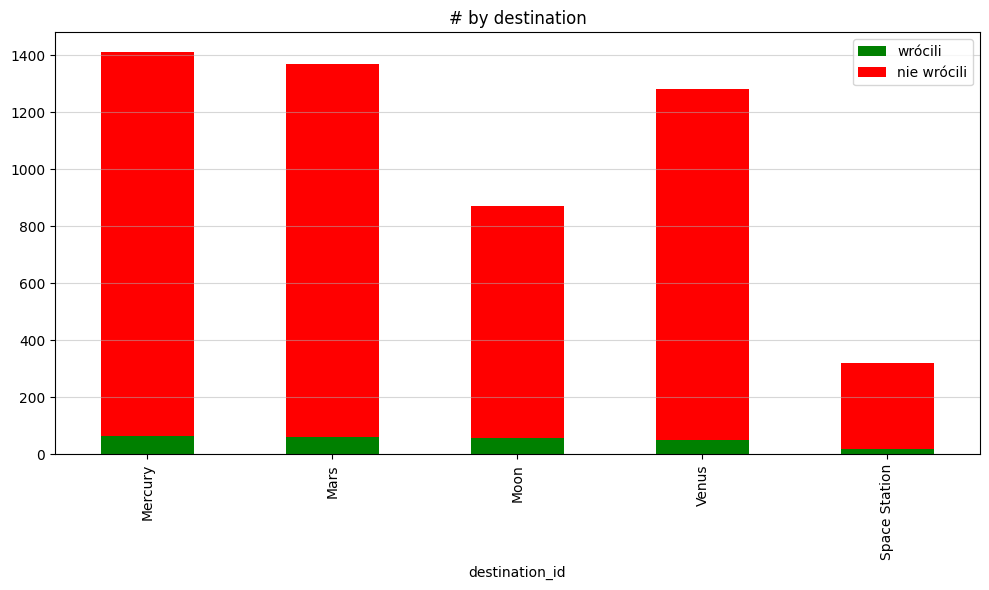

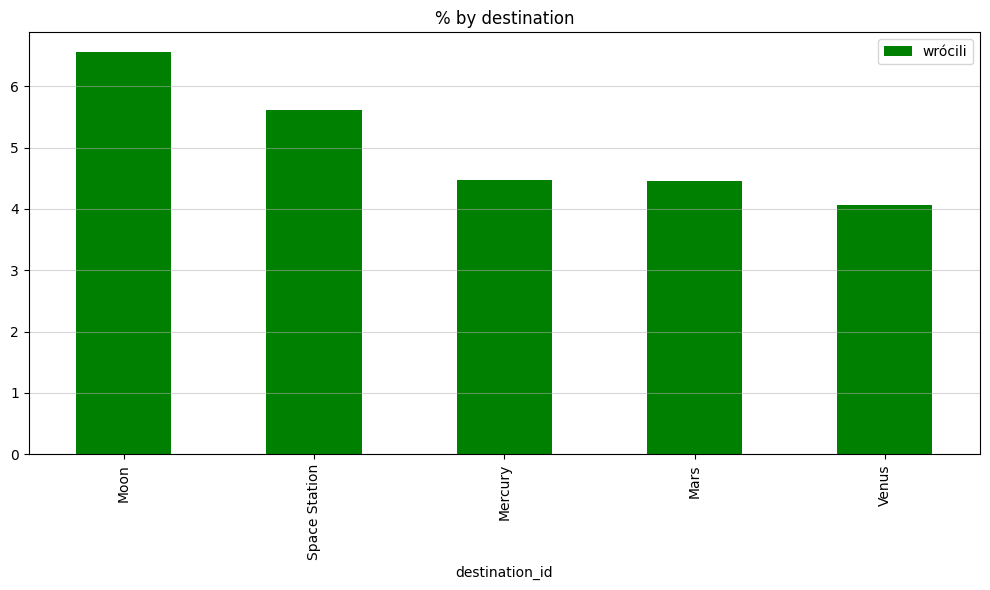

In [2]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import warnings
warnings.filterwarnings('ignore')

con = mysql.connector.connect(
    host = "giniewicz.it",
    user = "team07",
    password = "te@mlot",
    database = "team07"
)

query = """
SELECT tp.pesel, tp.trip_id, t.name AS trip_name, t.destination_id
FROM TripParticipants tp
JOIN Trips t ON tp.trip_id = t.trip_id
"""

df = pd.read_sql(query, con)

df_destinations = pd.read_sql("SELECT destination_id, name FROM Destinations", con)
df_destinations = df_destinations.set_index('destination_id')
con.close()

client_trips = df.groupby('pesel').agg(list)
destination_stats = defaultdict(lambda: {"returned": 0, "stopped": 0})
trip_to_destination = df.set_index('trip_id')['destination_id'].to_dict()

for trips in client_trips['trip_id']:
    for i, trip_id in enumerate(trips):
        destination = trip_to_destination[trip_id]
        if i < len(trips) - 1:
            destination_stats[destination]['returned'] += 1
        else:
            destination_stats[destination]['stopped'] += 1

result_df = pd.DataFrame.from_dict(destination_stats, orient='index')
result_df.index.name = 'Destination'
result_df = result_df.sort_values(by='returned',ascending=False)

ax = result_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=["green", "red"])
xticks = range(len(result_df))
labels = df_destinations.loc[result_df.index,'name']
plt.xticks(ticks=xticks,labels=labels)
plt.title("# by destination")
plt.xlabel("destination_id")
plt.legend(["wrócili", "nie wrócili"])
plt.tight_layout()
plt.grid(axis='y', alpha=0.5)
plt.show()

df_stats = pd.DataFrame.from_dict(destination_stats, orient='index')
df_stats.index.name = 'Destination'
df_stats['total'] = df_stats['returned'] + df_stats['stopped']
df_stats['returned_pct'] = 100 * df_stats['returned'] / df_stats['total']
df_stats['stopped_pct'] = 100 * df_stats['stopped'] / df_stats['total']
df_stats = df_stats.sort_values(by='returned_pct', ascending=False)

plot_df = df_stats[['returned_pct']]
ax = plot_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['green', 'red'])
xticks = range(len(plot_df))
labels = df_destinations.loc[plot_df.index,'name']
plt.xticks(ticks=xticks,labels=labels)
plt.title("% by destination")
plt.xlabel("destination_id")
plt.legend(["wrócili", "nie wrócili"])
plt.tight_layout()
plt.grid(axis='y', alpha=0.5)
plt.show()

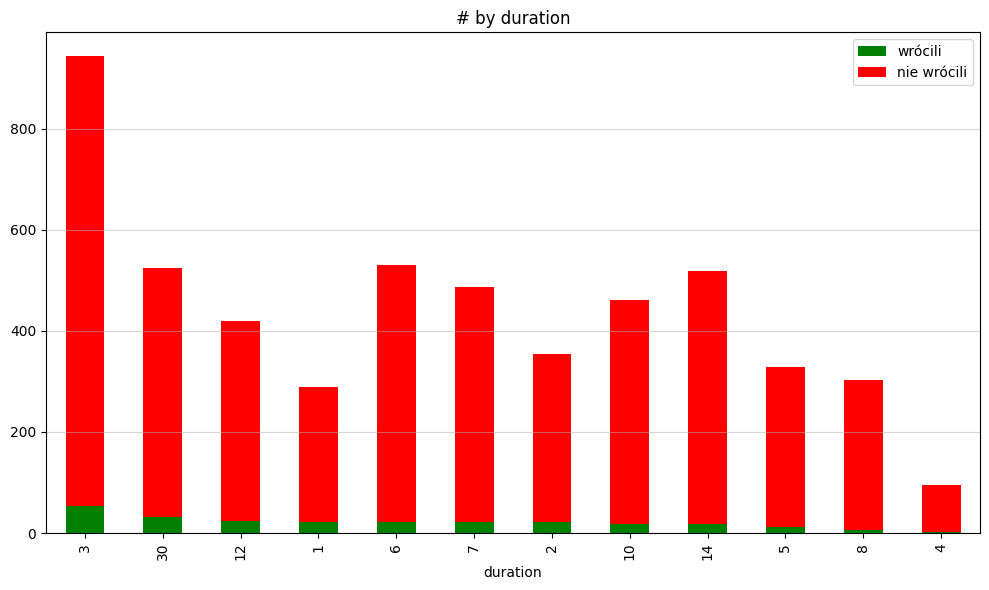

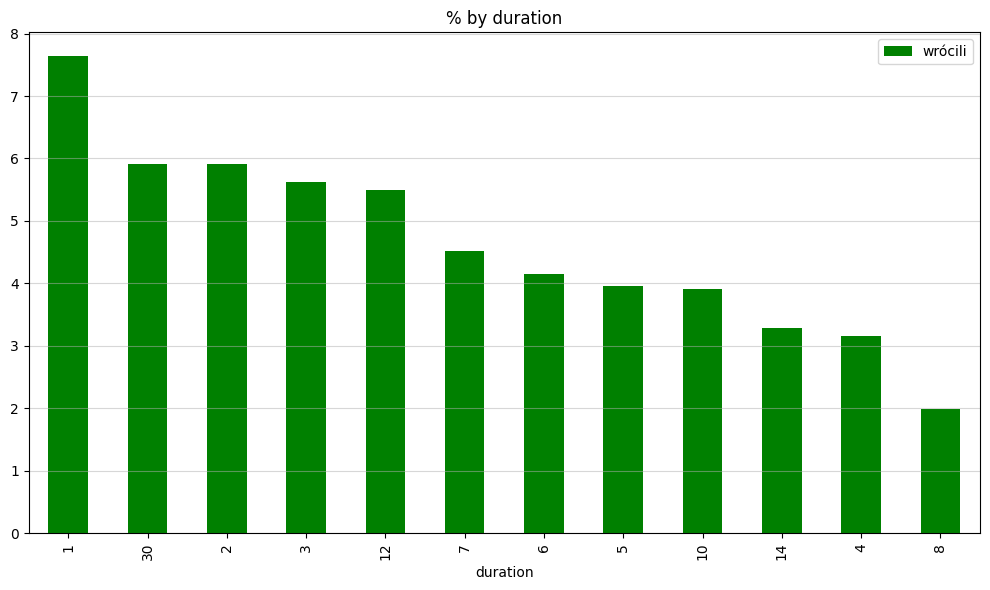

In [3]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

con = mysql.connector.connect(
    host = "giniewicz.it",
    user = "team07",
    password = "te@mlot",
    database = "team07"
)

query = """
SELECT tp.pesel, tp.trip_id, t.name AS trip_name, t.duration_of_stay
FROM TripParticipants tp
JOIN Trips t ON tp.trip_id = t.trip_id
ORDER BY tp.pesel, tp.trip_id
"""

df = pd.read_sql(query, con)
con.close()

client_trips = df.groupby('pesel').agg(list)
duration_stats = defaultdict(lambda: {"returned": 0, "stopped": 0})
trip_duration = df.set_index('trip_id')['duration_of_stay'].to_dict()

for trips in client_trips['trip_id']:
    for i, trip_id in enumerate(trips):
        duration = trip_duration[trip_id]
        if i < len(trips) - 1:
            duration_stats[duration]['returned'] += 1
        else:
            duration_stats[duration]['stopped'] += 1

result_df = pd.DataFrame.from_dict(duration_stats, orient='index')
result_df.index.name = 'Duration'
result_df = result_df.sort_values(by='returned', ascending=False)

ax = result_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=["green", "red"])
plt.title("# by duration")
plt.xlabel("duration")
plt.legend(["wrócili", "nie wrócili"])
plt.tight_layout()
plt.grid(axis='y', alpha=0.5)
plt.show()

df_stats = pd.DataFrame.from_dict(duration_stats, orient='index')
df_stats.index.name = 'Duration'
df_stats['total'] = df_stats['returned'] + df_stats['stopped']
df_stats['returned_pct'] = 100 * df_stats['returned'] / df_stats['total']
df_stats['stopped_pct'] = 100 * df_stats['stopped'] / df_stats['total']
df_stats = df_stats.sort_values(by='returned_pct', ascending=False)

plot_df = df_stats[['returned_pct']]
ax = plot_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['green', 'red'])
plt.title("% by duration")
plt.xlabel("duration")
plt.legend(["wrócili", "nie wrócili"])
plt.tight_layout()
plt.grid(axis='y', alpha=0.5)
plt.show()

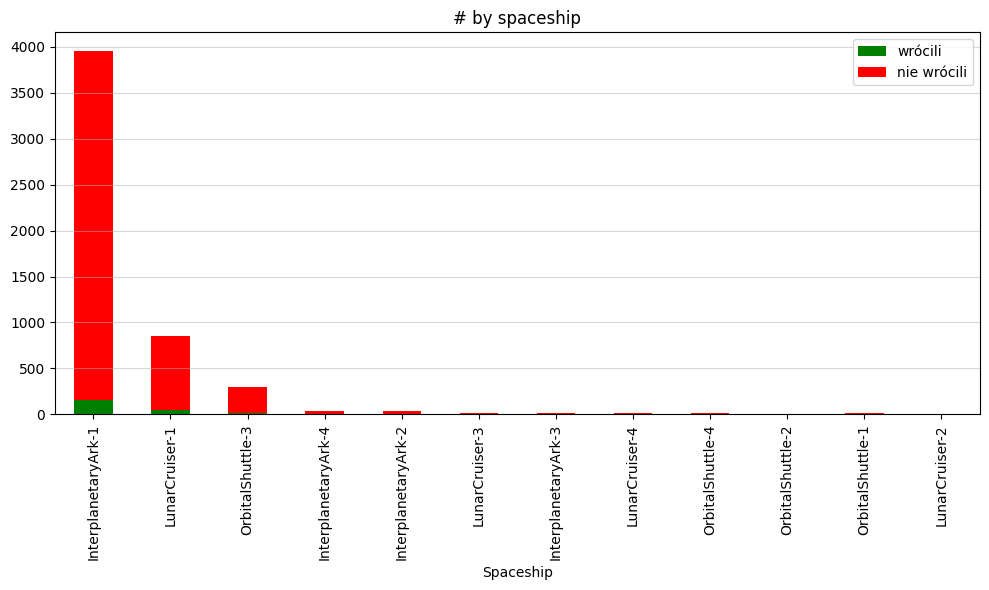

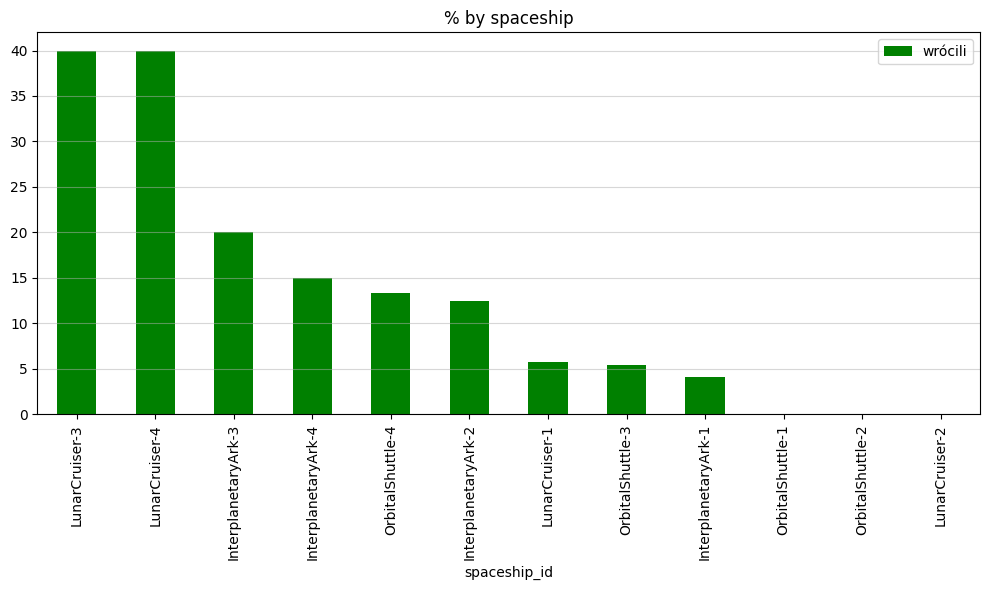

In [4]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

con = mysql.connector.connect(
    host = "giniewicz.it",
    user = "team07",
    password = "te@mlot",
    database = "team07"
)

query = """
SELECT tp.pesel, tp.trip_id, t.name AS trip_name, t.spaceship_id
FROM TripParticipants tp
JOIN Trips t ON tp.trip_id = t.trip_id
ORDER BY tp.pesel, tp.trip_id
"""

df = pd.read_sql(query, con)

df_spaceships = pd.read_sql("SELECT spaceship_id, name FROM Spaceships", con)
df_spaceships = df_spaceships.set_index('spaceship_id')
con.close()

client_trips = df.groupby('pesel').agg(list)
spaceship_stats = defaultdict(lambda: {"returned": 0, "stopped": 0})
trip_by_spaceship = df.set_index('trip_id')['spaceship_id'].to_dict()

for i in range(len(df_spaceships)):
    spaceship_stats[i+1]['returned'] = 0
    spaceship_stats[i+1]['stopped'] = 0

for trips in client_trips['trip_id']:
    for i, trip_id in enumerate(trips):
        spaceship = trip_by_spaceship[trip_id]
        if i < len(trips) - 1:
            spaceship_stats[spaceship]['returned'] += 1
        else:
            spaceship_stats[spaceship]['stopped'] += 1

result_df = pd.DataFrame.from_dict(spaceship_stats, orient='index')
result_df.index.name = 'Spaceship'
result_df = result_df.sort_values(by='returned', ascending=False)

ax = result_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=["green", "red"])
xticks = range(len(result_df))
labels = df_spaceships.loc[result_df.index,'name']
plt.xticks(ticks=xticks,labels=labels)
plt.title("# by spaceship")
plt.legend(["wrócili", "nie wrócili"])
plt.tight_layout()
plt.grid(axis='y', alpha=0.5)
plt.show()

df_stats = pd.DataFrame.from_dict(spaceship_stats, orient='index')
df_stats.index.name = 'Spaceship'
df_stats['total'] = df_stats['returned'] + df_stats['stopped']
df_stats['returned_pct'] = 100 * df_stats['returned'] / df_stats['total']
df_stats['stopped_pct'] = 100 * df_stats['stopped'] / df_stats['total']
df_stats = df_stats.sort_values(by='returned_pct', ascending=False)

plot_df = df_stats[['returned_pct']]
ax = plot_df.plot(kind='bar', stacked=True, figsize=(10, 6), color=['green', 'red'])
xticks = range(len(plot_df))
labels = df_spaceships.loc[plot_df.index,'name']
plt.xticks(ticks=xticks,labels=labels)
plt.title("% by spaceship")
plt.xlabel("spaceship_id")
plt.legend(["wrócili", "nie wrócili"])
plt.tight_layout()
plt.grid(axis='y', alpha=0.5)
plt.show()